Este proyecto pretende detectar si una reclamacion de accidente vehicular es fraude o no

In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('fraud_oracle.csv')

### Diccionario de Datos

| Variable | Tipo | ¿Qué significa? |
| :--- | :--- | :--- |
| Month | Texto | Mes en el que ocurrió el accidente. |
| WeekOfMonth | Número | Semana del mes en la que ocurrió el accidente. |
| DayOfWeek | Texto | Día de la semana en el que ocurrió el accidente. |
| Make | Texto | Marca del vehículo involucrado. |
| AccidentArea | Texto | Tipo de zona donde ocurrió el accidente (Urbano o Rural). |
| DayOfWeekClaimed | Texto | Día de la semana en el que se realizó la reclamación. |
| MonthClaimed | Texto | Mes en el que se realizó la reclamación. |
| WeekOfMonthClaimed | Número | Semana del mes en la que se realizó la reclamación. |
| Sex | Texto | Género del conductor involucrado. |
| MaritalStatus | Texto | Estado civil del conductor. |
| Age | Número | Edad del conductor involucrado  |
| Fault | Texto | Quién fue determinado como culpable (Titular de la póliza o Tercero). |
| PolicyType | Texto | Combinación de categoría de vehículo y tipo de cobertura. |
| VehicleCategory | Texto | Categoría del vehículo (Sedán, Deportivo, Utilitario). |
| VehiclePrice | Texto (Rango) | Rango de precio del vehículo asegurado. |
| FraudFound_P | Binario (0/1) | Indica si se detectó fraude en la reclamación (1: Sí, 0: No). |
| PolicyNumber | Número | Identificador único de la póliza. |
| RepNumber | Número | Identificador del representante que procesó el caso. |
| Deductible | Número | Monto del deducible de la póliza. |
| DriverRating | Número | Calificación del conductor (1 a 4). |
| Days_Policy_Accident | Texto (Rango) | Tiempo transcurrido desde el inicio de la póliza hasta el accidente. |
| Days_Policy_Claim | Texto (Rango) | Tiempo transcurrido desde el inicio de la póliza hasta la reclamación. |
| PastNumberOfClaims | Texto (Rango) | Número de reclamaciones realizadas anteriormente por el asegurado. |
| AgeOfVehicle | Texto (Rango) | Antigüedad del vehículo involucrado. |
| AgeOfPolicyHolder | Texto (Rango) | Rango de edad del titular de la póliza. |
| PoliceReportFiled | Texto (Sí/No) | Indica si se presentó un informe policial del accidente. |
| WitnessPresent | Texto (Sí/No) | Indica si hubo testigos presentes en el accidente. |
| AgentType | Texto | Tipo de agente (Interno o Externo). |
| NumberOfSuppliments | Texto (Rango) | Cantidad de suplementos o anexos añadidos a la reclamación. |
| AddressChange_Claim | Texto | Indica si hubo un cambio de dirección durante el proceso de reclamación. |
| NumberOfCars | Texto (Rango) | Cantidad de vehículos involucrados en el incidente. |
| Year | Número | Año en el que ocurrió el accidente. |
| BasePolicy | Texto | Tipo de cobertura base (Responsabilidad Civil, Colisión, Todo Riesgo). |

In [5]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [6]:
df.describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


con df.describe pudimos identificar varias cosas: 
1. que el porcentaje de fraudes encontrados es 5.9% 
2. que edad tiene datos en 0 

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [8]:
df.isnull().sum().to_string()

'Month                   0\nWeekOfMonth             0\nDayOfWeek               0\nMake                    0\nAccidentArea            0\nDayOfWeekClaimed        0\nMonthClaimed            0\nWeekOfMonthClaimed      0\nSex                     0\nMaritalStatus           0\nAge                     0\nFault                   0\nPolicyType              0\nVehicleCategory         0\nVehiclePrice            0\nFraudFound_P            0\nPolicyNumber            0\nRepNumber               0\nDeductible              0\nDriverRating            0\nDays_Policy_Accident    0\nDays_Policy_Claim       0\nPastNumberOfClaims      0\nAgeOfVehicle            0\nAgeOfPolicyHolder       0\nPoliceReportFiled       0\nWitnessPresent          0\nAgentType               0\nNumberOfSuppliments     0\nAddressChange_Claim     0\nNumberOfCars            0\nYear                    0\nBasePolicy              0'

No hay valores nulos entonces, vamos a mirar duplicados, tipos de datos y cuales columnas si son relevantes y cuales no 

In [9]:
df.duplicated().sum()

np.int64(0)

Tampoco hay duplicados, continuamos con investigar la columna de edad porq edad = 0 es ilogico

In [10]:
df['Age'].unique()

array([21, 34, 47, 65, 27, 20, 36,  0, 30, 42, 71, 52, 28, 61, 38, 41, 32,
       40, 63, 31, 45, 60, 39, 55, 35, 44, 72, 29, 37, 59, 49, 50, 26, 48,
       64, 33, 74, 23, 25, 56, 16, 68, 18, 51, 22, 53, 46, 43, 57, 54, 69,
       67, 19, 78, 77, 75, 80, 58, 73, 24, 76, 62, 79, 70, 17, 66])

miremos cuantas filas tienen edad = 0


In [11]:
df[df['Age'] ==0]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
13,Jan,5,Friday,Honda,Rural,Wednesday,Feb,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
28,Jul,1,Saturday,Honda,Urban,Tuesday,Sep,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils
31,Mar,1,Sunday,Honda,Urban,Tuesday,Mar,2,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
58,May,1,Monday,Honda,Rural,Wednesday,May,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Liability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15243,May,2,Tuesday,Honda,Urban,Monday,May,3,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15262,Mar,3,Monday,Honda,Urban,Thursday,Mar,3,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability
15274,Apr,3,Monday,Honda,Urban,Tuesday,May,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1996,Collision
15379,Jan,2,Tuesday,Honda,Urban,Thursday,Jan,2,Male,Single,...,new,16 to 17,No,No,External,none,1 year,1 vehicle,1996,All Perils


se identifico que todas las filas de AGE que tienen "0", en "AgeOfPolicyHolder" tienen "16 to 17"	

In [12]:
df.loc[df ['Age']== 0, 'AgeOfPolicyHolder'].unique()

<StringArray>
['16 to 17']
Length: 1, dtype: str

Entonces voy a mirar que dato tienew AGE en las otras filas que "AgeOfPolicyHolder" tiene "16 to 17"

In [13]:
df[df['AgeOfPolicyHolder'] == "16 to 17"][["Age", "AgeOfPolicyHolder"]]


,Age,AgeOfPolicyHolder
7,0,16 to 17
13,0,16 to 17
28,0,16 to 17
31,0,16 to 17
58,0,16 to 17
...,...,...
15243,0,16 to 17
15262,0,16 to 17
15274,0,16 to 17
15379,0,16 to 17


Todos los datos de la  columna "Age" cuando  "AgeOfPolicyHolders" es igual a "16 to 17" son "0" entonces no podriamos reemplazar por algun dato existente. Continuamos revisando otras variables y ma adelante tomaremos decision sobre que hacer con esto con encontramos


Voy a verificar si en PolicyNumber hay duplicados, loq ue significaria que hay multiples reclamaciones de una poliza, en caso de que no existan duplicaciones esta columna podria eliminarse


In [14]:
df[df.duplicated(['PolicyNumber'])]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy


efectivamente, no hay duplicados entonces la eliminaremos

In [15]:
df.drop('PolicyNumber', axis = 1, inplace = True)

Ahora eliminemos las columnas que no tengan relevancia 

In [16]:
df = df.drop(columns=[
    'MaritalStatus', 'Month', 'WeekOfMonth', 'DayOfWeek', 
    'MonthClaimed', 'WeekOfMonthClaimed', 'DayOfWeekClaimed', 
    'RepNumber', 'AgentType', 'AddressChange_Claim', 'Year','NumberOfSuppliments'])

Eliminamos las fechas tanto en las que ocurrio el accidente como en la que hicieron la reclamacion, ya que los datos que nos podrian servir son estos: Days_Policy_Accident y Days_Policy_Claim

In [17]:
df['Days_Policy_Accident'].unique()

<StringArray>
['more than 30', '15 to 30', 'none', '1 to 7', '8 to 15']
Length: 5, dtype: str

In [18]:
df['Days_Policy_Claim'].unique()

<StringArray>
['more than 30', '15 to 30', '8 to 15', 'none']
Length: 4, dtype: str

Ahora tenemos dos opciones, rellenar esos "0" con 16 para que este acorde al "AgeOfPolicyholder" o graficar a traves de un boxplot para determinar si reemplazamos por la media o por la mediana

En caso de que decidamos que si vamos a convertir esos '0' a '16': 
df['Age'] = df['Age'].replace('0', '16')

Vamos a graficar con un boxplot a ver que encontramos

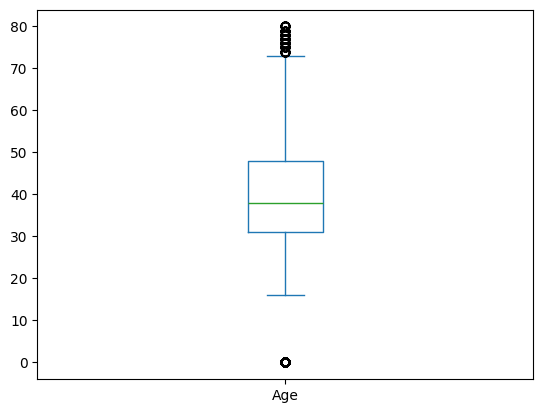

In [19]:
df['Age'].plot(kind='box')
plt.show()

Encontramos que hay datos extremos o atipicos tanto "0" como mas de "75", por lo tanto vamos a reemplazar el 0 por la mediana ya que si lo hicieramos por la media los datos atipicos afectarian de mal manera el resultado

In [20]:
df.loc[df['Age'] == 0, 'Age'] = df['Age'].median()

In [21]:

df['Age'].unique()

array([21, 34, 47, 65, 27, 20, 36, 38, 30, 42, 71, 52, 28, 61, 41, 32, 40,
       63, 31, 45, 60, 39, 55, 35, 44, 72, 29, 37, 59, 49, 50, 26, 48, 64,
       33, 74, 23, 25, 56, 16, 68, 18, 51, 22, 53, 46, 43, 57, 54, 69, 67,
       19, 78, 77, 75, 80, 58, 73, 24, 76, 62, 79, 70, 17, 66])

Como ya tenemos estos datos bien organizados, encontramos que la columna "AgePolicyOfHolder" es redudante, por lo tanto la eliminamos

In [22]:
df = df.drop(columns=['AgeOfPolicyHolder'])

In [23]:

df['PastNumberOfClaims'].unique()

<StringArray>
['none', '1', '2 to 4', 'more than 4']
Length: 4, dtype: str

In [24]:
df.columns

Index(['Make', 'AccidentArea', 'Sex', 'Age', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'PoliceReportFiled',
       'WitnessPresent', 'NumberOfCars', 'BasePolicy'],
      dtype='str')

In [25]:
df.dtypes


Make                      str
AccidentArea              str
Sex                       str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            int64
Deductible              int64
DriverRating            int64
Days_Policy_Accident      str
Days_Policy_Claim         str
PastNumberOfClaims        str
AgeOfVehicle              str
PoliceReportFiled         str
WitnessPresent            str
NumberOfCars              str
BasePolicy                str
dtype: object

pongamos en binario las variables que deban estarlo, como la de area de accidente, etc.

In [26]:
binarizacion = {
    'Sex': {"Female": 1, "Male": 0},
    'WitnessPresent': {"Yes": 1, "No": 0},
    'AccidentArea': {"Urban": 1, "Rural": 0},
    'PoliceReportFiled': {"Yes": 1, "No": 0},
    'Fault': {'Policy Holder': 1, 'Third Party': 0}
}

for col, mapa in binarizacion.items():
    df[col] = df[col].map(mapa)

| Columna           | Valores probables           | Tipo    | Tratamiento |
| ----------------- | --------------------------- | ------- |-------------|
| Fault             | Policy Holder / Third Party | Binaria | 1/0         |
| PoliceReportFiled | Yes / No                    | Binaria | 1/0         |
| WitnessPresent    | Yes / No                    | Binaria | 1/0         |
| AccidentArea      | Urban / Rural               | Binaria | 1/0         |
| Sex               | Female / Male               | Binaria | 1/0         |


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Make                  15420 non-null  str  
 1   AccidentArea          15420 non-null  int64
 2   Sex                   15420 non-null  int64
 3   Age                   15420 non-null  int64
 4   Fault                 15420 non-null  int64
 5   PolicyType            15420 non-null  str  
 6   VehicleCategory       15420 non-null  str  
 7   VehiclePrice          15420 non-null  str  
 8   FraudFound_P          15420 non-null  int64
 9   Deductible            15420 non-null  int64
 10  DriverRating          15420 non-null  int64
 11  Days_Policy_Accident  15420 non-null  str  
 12  Days_Policy_Claim     15420 non-null  str  
 13  PastNumberOfClaims    15420 non-null  str  
 14  AgeOfVehicle          15420 non-null  str  
 15  PoliceReportFiled     15420 non-null  int64
 16  WitnessPresent 

dado que las variables deben ser numericas para calcular correlaciones y para que el modelo de ML lo entienda vamos a convertirlas en numeros

In [28]:
df['PastNumberOfClaims'].unique()

<StringArray>
['none', '1', '2 to 4', 'more than 4']
Length: 4, dtype: str

In [29]:
df['NumberOfCars'].unique()

<StringArray>
['3 to 4', '1 vehicle', '2 vehicles', '5 to 8', 'more than 8']
Length: 5, dtype: str

In [30]:
df['VehiclePrice'].unique()

<StringArray>
['more than 69000',  '20000 to 29000',  '30000 to 39000', 'less than 20000',
  '40000 to 59000',  '60000 to 69000']
Length: 6, dtype: str

In [31]:
df['AgeOfVehicle'].unique()

<StringArray>
[    '3 years',     '6 years',     '7 years', 'more than 7',     '5 years',
         'new',     '4 years',     '2 years']
Length: 8, dtype: str

In [32]:
df.columns = df.columns.str.strip()

df['PastNumberOfClaims'] = df['PastNumberOfClaims'].str.strip().map({
    'none': 0,
    '1': 1,            
    '2 to 4': 3,          
    'more than 4': 5
})

df['NumberOfCars'] = df['NumberOfCars'].str.strip().map({
    '1 vehicle': 1,
    '2 vehicles': 2,
    '3 to 4': 3.5,   
    '5 to 8': 6.5,
    'more than 8': 9
})

df['VehiclePrice'] = df['VehiclePrice'].str.strip().map({
    'less than 20000': 15000,
    '20000 to 29000': 24500,
    '30000 to 39000': 34500,
    '40000 to 59000': 49500,        
    '60000 to 69000': 64500,
    'more than 69000': 70000
})

df['Days_Policy_Accident'] = df['Days_Policy_Accident'].str.strip().map({
    'none': 0,
    '1 to 7': 4,
    '8 to 15': 11,              
    '15 to 30': 22,
    'more than 30': 40
})

df['Days_Policy_Claim'] = df['Days_Policy_Claim'].str.strip().map({
    'none': 0,
    '8 to 15': 11,
    '15 to 30': 22,              
    'more than 30': 40
})

df['AgeOfVehicle'] = df['AgeOfVehicle'].str.strip().map({
    'new': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,        
    '6 years': 6,
    '7 years': 7,
    'more than 7': 10
})




In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  15420 non-null  str    
 1   AccidentArea          15420 non-null  int64  
 2   Sex                   15420 non-null  int64  
 3   Age                   15420 non-null  int64  
 4   Fault                 15420 non-null  int64  
 5   PolicyType            15420 non-null  str    
 6   VehicleCategory       15420 non-null  str    
 7   VehiclePrice          15420 non-null  int64  
 8   FraudFound_P          15420 non-null  int64  
 9   Deductible            15420 non-null  int64  
 10  DriverRating          15420 non-null  int64  
 11  Days_Policy_Accident  15420 non-null  int64  
 12  Days_Policy_Claim     15420 non-null  int64  
 13  PastNumberOfClaims    15420 non-null  int64  
 14  AgeOfVehicle          15420 non-null  int64  
 15  PoliceReportFiled     15420 no

In [34]:
df['Make'].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [35]:
df['Make'] = df['Make'].replace({
    'Accura': 'Acura',
    'Nisson': 'Nissan',
    'Porche': 'Porsche',
    'Mecedes': 'Mercedes'
})

In [36]:
df['Make'].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Acura         472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nissan         30
BMW            15
Jaguar          6
Porsche         5
Mercedes        4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [37]:
frec_marcas = df['Make'].value_counts().nlargest(8).index

In [38]:
df['Make'] = df['Make'].apply(
    lambda x: x if x in frec_marcas else 'Other'
)

In [39]:
df['Make'].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Acura         472
Ford          450
Other         421
VW            283
Name: count, dtype: int64

ahora las variables que faltan hagamos dummies


In [40]:
df = pd.get_dummies(df, columns=[
    'Make',
    'PolicyType',
    'VehicleCategory',
    'BasePolicy'
], drop_first=True)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   AccidentArea                     15420 non-null  int64  
 1   Sex                              15420 non-null  int64  
 2   Age                              15420 non-null  int64  
 3   Fault                            15420 non-null  int64  
 4   VehiclePrice                     15420 non-null  int64  
 5   FraudFound_P                     15420 non-null  int64  
 6   Deductible                       15420 non-null  int64  
 7   DriverRating                     15420 non-null  int64  
 8   Days_Policy_Accident             15420 non-null  int64  
 9   Days_Policy_Claim                15420 non-null  int64  
 10  PastNumberOfClaims               15420 non-null  int64  
 11  AgeOfVehicle                     15420 non-null  int64  
 12  PoliceReportFiled            

In [42]:
pd.set_option('display.max_rows', None)

print(df.corr()['FraudFound_P'].sort_values(ascending=False))

FraudFound_P                       1.000000
Fault                              0.131389
PolicyType_Sport - Collision       0.050010
BasePolicy_Collision               0.043860
PolicyType_Utility - All Perils    0.038441
VehicleCategory_Utility            0.035815
VehiclePrice                       0.033837
PolicyType_Sedan - Collision       0.028302
Deductible                         0.017348
Make_Ford                          0.009849
NumberOfCars                       0.008507
Make_Honda                         0.008040
PolicyType_Utility - Collision     0.007471
DriverRating                       0.007266
Make_Other                         0.004697
Make_Toyota                       -0.000554
PolicyType_Sport - Liability      -0.002032
Make_Chevrolet                    -0.005807
WitnessPresent                    -0.008057
PolicyType_Utility - Liability    -0.009318
PolicyType_Sport - All Perils     -0.009538
Make_Pontiac                      -0.010542
Make_Mazda                      

intentemos mostrar solo las que tengan valores mas altos a 0.03

In [45]:
corr = df.corr()['FraudFound_P']

variables_importantes = corr[abs(corr) > 0.03]
print(variables_importantes.sort_values(ascending=False))

FraudFound_P                       1.000000
Fault                              0.131389
PolicyType_Sport - Collision       0.050010
BasePolicy_Collision               0.043860
PolicyType_Utility - All Perils    0.038441
VehicleCategory_Utility            0.035815
VehiclePrice                       0.033837
AgeOfVehicle                      -0.031441
AccidentArea                      -0.033499
PastNumberOfClaims                -0.057340
VehicleCategory_Sport             -0.135903
PolicyType_Sedan - Liability      -0.153413
BasePolicy_Liability              -0.154007
Name: FraudFound_P, dtype: float64


y ahora que hago con esta monda si ninguna tiene correlacion fuerte